In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("supply_chain_data.csv")

In [5]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [6]:
df.describe()


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [7]:
df.nunique()

Product type                 3
SKU                        100
Price                      100
Availability                63
Number of products sold     96
Revenue generated          100
Customer demographics        4
Stock levels                65
Lead times                  29
Order quantities            61
Shipping times              10
Shipping carriers            3
Shipping costs             100
Supplier name                5
Location                     5
Lead time                   29
Production volumes          96
Manufacturing lead time     30
Manufacturing costs        100
Inspection results           3
Defect rates               100
Transportation modes         4
Routes                       3
Costs                      100
dtype: int64

In [ ]:
#KPI section

In [10]:
total_revenue = df['Revenue generated'].sum()
print("Total Revenue:",round(total_revenue,2))

Total Revenue: 577604.82


In [11]:
avg_revenue = df['Revenue generated'].mean()
print("Average Revenue:",round(avg_revenue,2))

Average Revenue: 5776.05


In [3]:
total_sku = df['SKU'].nunique()
print("Total SKUs:", total_sku)

Total SKUs: 100


In [4]:
total_sold = df['Number of products sold'].sum()
print("Products Sold:", total_sold)

Products Sold: 46099


In [5]:
avg_stock = df['Stock levels'].mean()
print("Average Stock Level:",round(avg_stock,2))

Average Stock Level: 47.77


In [6]:
avg_ship = df['Shipping costs'].mean()
print("Average Shipping Cost:",round(avg_ship,2))

Average Shipping Cost: 5.55


In [8]:
product_revenue = (df.groupby('Product type')['Revenue generated'].sum().sort_values(ascending=False))
product_revenue

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64

In [10]:
df.groupby('Product type')['Number of products sold'] \
    .sum().sort_values(ascending=False)

Product type
skincare     20731
haircare     13611
cosmetics    11757
Name: Number of products sold, dtype: int64

In [11]:
df.groupby('Product type')['Price'] \
.mean().sort_values(ascending=False)

Product type
cosmetics    57.361058
skincare     47.259329
haircare     46.014279
Name: Price, dtype: float64

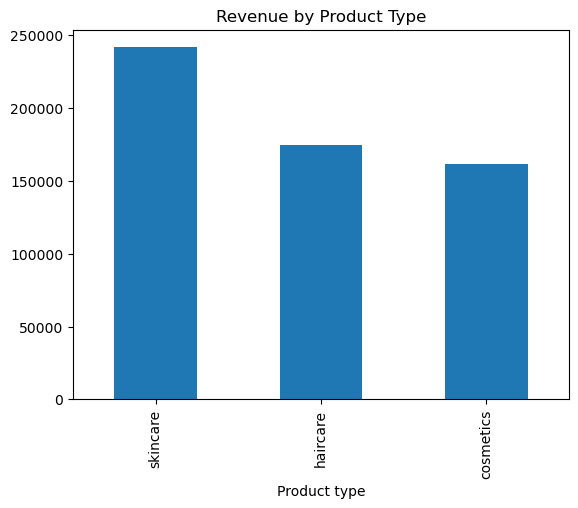

In [13]:
product_revenue.plot(kind='bar')
plt.title('Revenue by Product Type')
plt.show()

In [ ]:
#SUPPLIER ANALYSIS

In [14]:
df.groupby('Supplier name')['Revenue generated'] \
.sum().sort_values(ascending=False)

Supplier name
Supplier 1    157528.995039
Supplier 2    125467.418605
Supplier 5    110343.463656
Supplier 3     97795.979638
Supplier 4     86468.961799
Name: Revenue generated, dtype: float64

In [15]:
df.groupby('Supplier name')['Defect rates'] \
.mean().sort_values(ascending=False)

Supplier name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: Defect rates, dtype: float64

In [16]:
df.groupby('Product type')['Stock levels'] \
.mean().sort_values(ascending=False)

Product type
cosmetics    58.653846
haircare     48.352941
skincare     40.200000
Name: Stock levels, dtype: float64

In [25]:
low_stock = df[
    df['Stock levels']
    < df['Stock levels'].quantile(0.25)
]

low_stock[['SKU','Product type','Stock levels']]

,SKU,Product type,Stock levels
2,SKU2,haircare,1
4,SKU4,skincare,5
6,SKU6,skincare,11
8,SKU8,cosmetics,5
9,SKU9,skincare,14
15,SKU15,skincare,9
16,SKU16,skincare,2
18,SKU18,haircare,10
24,SKU24,haircare,4
31,SKU31,skincare,6


In [28]:
df.groupby('Product type')['Availability'] \
.mean().sort_values(ascending=False)

Product type
cosmetics    51.230769
skincare     50.925000
haircare     43.264706
Name: Availability, dtype: float64

In [ ]:
#LOGISTICS ANALYSIS

In [29]:
df.groupby('Shipping carriers')['Shipping costs'] \
.mean().sort_values(ascending=False)

Shipping carriers
Carrier C    5.599292
Carrier A    5.554923
Carrier B    5.509247
Name: Shipping costs, dtype: float64

In [30]:
df.groupby('Shipping carriers')['Shipping times'] \
.mean().sort_values(ascending=False)

Shipping carriers
Carrier A    6.142857
Carrier C    6.034483
Carrier B    5.302326
Name: Shipping times, dtype: float64

In [31]:
df.groupby('Transportation modes')['Shipping costs'].mean()

Transportation modes
Air     6.017839
Rail    5.469098
Road    5.542115
Sea     4.970294
Name: Shipping costs, dtype: float64

In [53]:
df.groupby('Product type')['Defect rates'].mean().sort_values(ascending=False)

Product type
haircare     2.483150
skincare     2.334681
cosmetics    1.919287
Name: Defect rates, dtype: float64

In [34]:
df['Inspection results'].value_counts()

Inspection results
Pending    41
Fail       36
Pass       23
Name: count, dtype: int64

num_cols = df.select_dtypes(include='number')

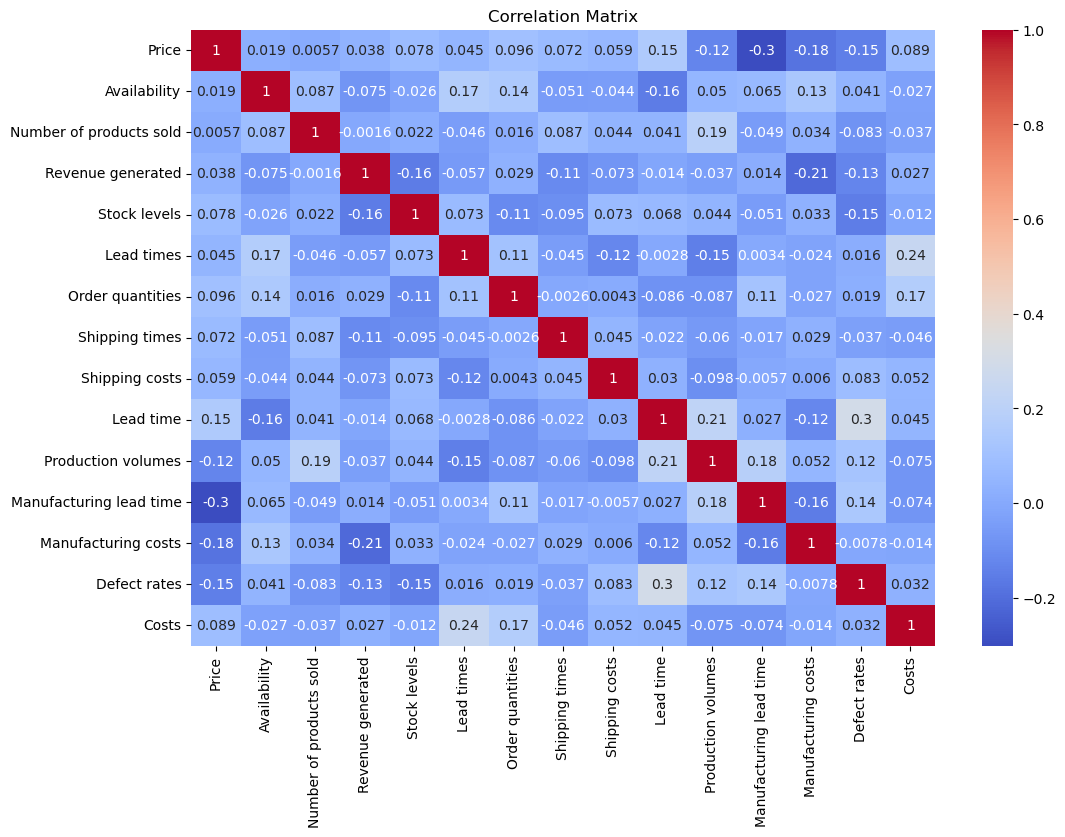

In [43]:
import seaborn as sns 
import matplotlib.pyplot as plt
num_cols = df.select_dtypes(include='number')
plt.figure(figsize=(12,8))
sns.heatmap(
            num_cols.corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

<Axes: xlabel='Product type', ylabel='Revenue generated'>

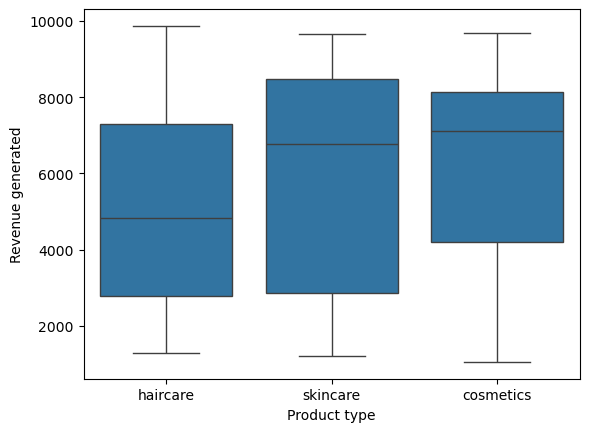

In [44]:
sns.boxplot(data=df, x='Product type', y='Revenue generated')

<Axes: xlabel='Shipping costs', ylabel='Shipping times'>

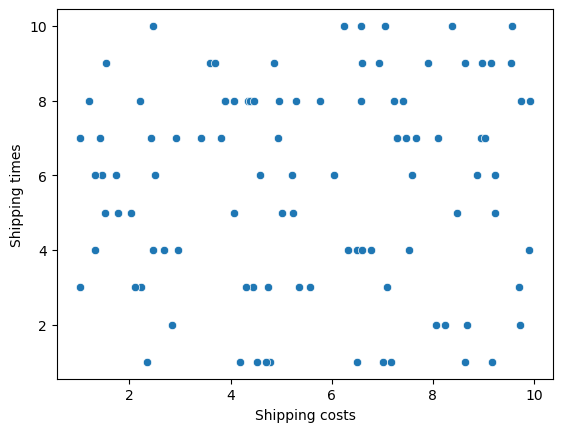

In [45]:
sns.scatterplot(
    data=df,
    x='Shipping costs',
    y='Shipping times'
)    

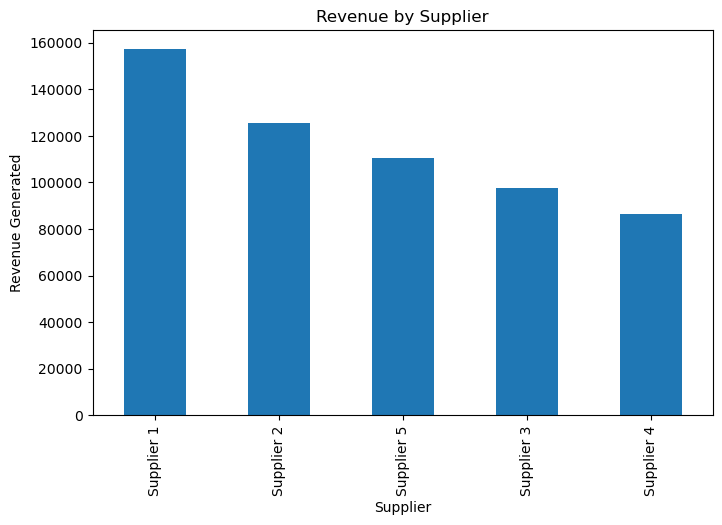

In [47]:
supplier_revenue = df.groupby('Supplier name')['Revenue generated'] \
.sum().sort_values(ascending=False)
supplier_revenue.plot(
    kind='bar',
    figsize=(8,5),
    title='Revenue by Supplier'
)
plt.xlabel('Supplier')
plt.ylabel('Revenue Generated')
plt.show()

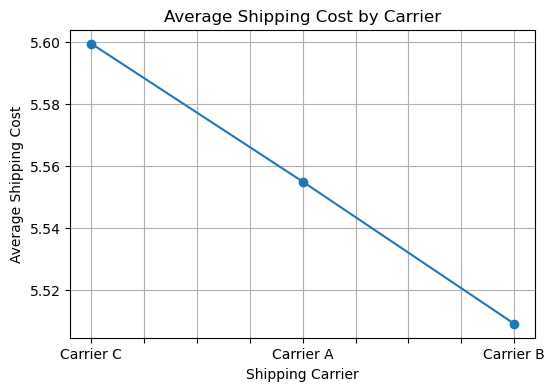

In [52]:
import matplotlib.pyplot as plt
shipping_cost = df.groupby('Shipping carriers')['Shipping costs'] \
.mean().sort_values(ascending=False)
shipping_cost.plot(kind='line',marker='o',figsize=(6,4))
plt.title('Average Shipping Cost by Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Average Shipping Cost')
plt.grid(True)
plt.show()